feeding (log-)mel-spectrogram into a CNN instead of hand-picking MFCCs, the convolutional filters take over the role the DCT played — but more flexibly. Early conv layers act like local edge/onset detectors across small time-frequency patches (not unlike what delta features hand-encode: "is energy rising or falling here"). Deeper layers combine these into larger, more abstract patterns — formant-transition detectors, then phoneme-like or speaker-like detectors. The key difference: MFCC's DCT is a fixed, hand-designed basis that intentionally discards pitch; a CNN's filters are learned from data and aren't committed to throwing anything away. That's exactly why many modern speech and speaker-recognition systems feed CNNs the log-mel-spectrogram directly rather than the truncated MFCCs — the network can decide for itself whether pitch information is worth keeping.

In [ ]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("taresh18/AnimeVox")

# Access the training split
train_data = dataset["train"]

# Print dataset information
print(f"Dataset contains {len(train_data)} samples")

# Access a specific sample
sample = train_data[0]
print(f"Character: {sample['character_name']}")
print(f"From anime: {sample['anime']}")
print(f"Transcription: {sample['transcription']}")

Liborsa module help us alter audio , play the audio and use mfcc , mel spectogram, etc

In [ ]:
import numpy as np
import librosa
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
!pip install lightning
import lightning as L
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

In [11]:

# ============================================================
# CONFIG
# ============================================================
SR = 44100
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

FMAX = SR/2
FIXED_DURATION_SEC = 3.0    # every clip is padded/truncated to this length
FIXED_FRAMES = int(np.ceil(SR * FIXED_DURATION_SEC / HOP_LENGTH))
MIN_SAMPLES_PER_CLASS = 5
BATCH_SIZE = 32
MAX_EPOCHS = 13
LEARNING_RATE = 1e-3
RANDOM_STATE = 42

counter is a inbuild which counts the unique label and there sizes we first are filtering character with less smaples we are keeping their indexes in keep index then creating a new dataset with those charaters

In [4]:
label_counts = Counter(train_data['character_name'])
valid_chars = {c for c, n in label_counts.items() if n >= MIN_SAMPLES_PER_CLASS}
keep_idx = [i for i, c in enumerate(train_data['character_name']) if c in valid_chars]
filtered_data = train_data.select(keep_idx)
print(f"Kept {len(valid_chars)} characters, {len(filtered_data)} samples")

Kept 19 characters, 11020 samples


splitting the data into train and test
stratify ensure that we pick 0.8 for test and 0.2 for each character
ques) why we splitting so -> Splitting early matters immensely because it prevents data leakage.
we are only giving the index and there labels
we are going to find train_idx and test_idx and validation and they from the last filtererd dataset we
are selecting new two data set

In [5]:

indices = list(range(len(filtered_data)))
labels = filtered_data['character_name']

train_idx, test_idx = train_test_split(
    indices, test_size=0.2, stratify=labels, random_state=RANDOM_STATE
)
train_labels_tmp = [labels[i] for i in train_idx]
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.1, stratify=train_labels_tmp, random_state=RANDOM_STATE
)

train_split = filtered_data.select(train_idx)
val_split = filtered_data.select(val_idx)
test_split = filtered_data.select(test_idx)
print(f"Train: {len(train_split)} | Val: {len(val_split)} | Test: {len(test_split)}")







Train: 7934 | Val: 882 | Test: 2204


A standard sound wave only tells you how loud an audio signal is at any given instant. A spectrogram breaks that sound down into its underlying frequencies (low bass, mid-range, high treble) across time.

The "Mel" part comes from the Mel scale (short for melody). Human hearing does not perceive pitch in a straight linear line:

We can easily tell the difference between 100 Hz and 200 Hz.

We struggle to tell the difference between 10,000 Hz and 10,100 Hz, even though the distance in Hz is identical.

The Mel scale warps standard frequencies so that equal distances on the graph equal humanly perceived differences in pitch.

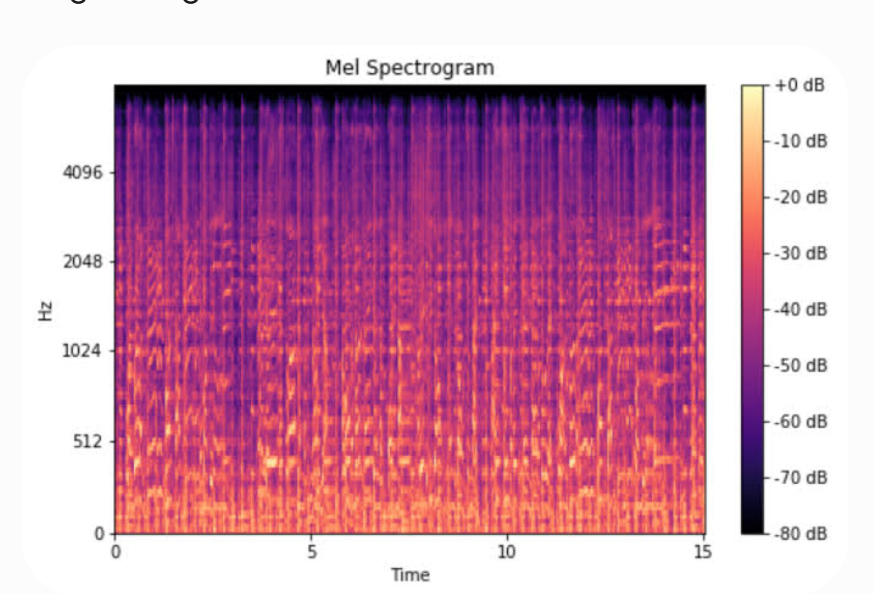

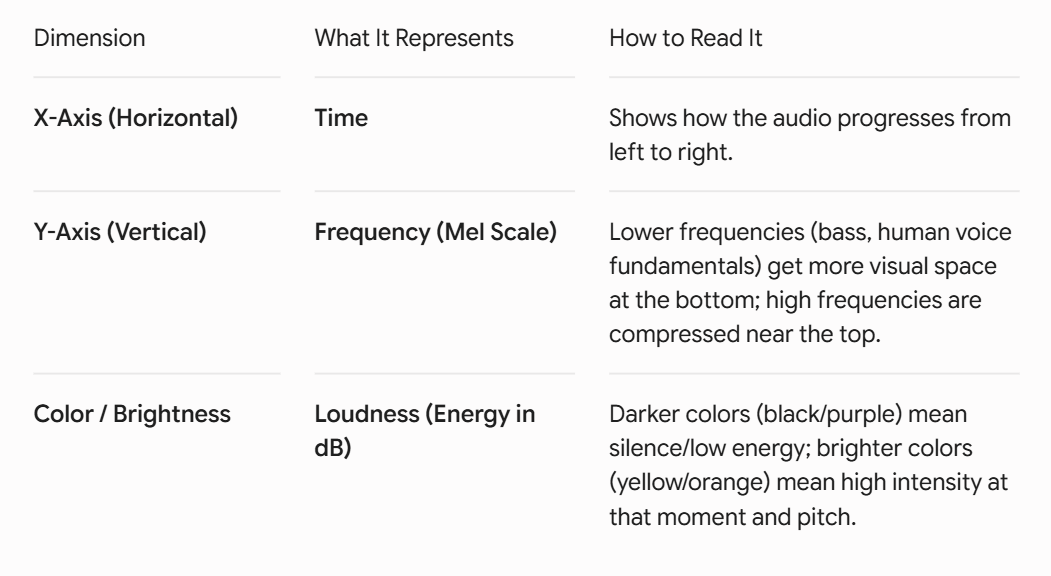

In [6]:

# STEP 3: Feature extraction

def extract_features(audio_array, sr):
    if audio_array is None or len(audio_array) == 0:
        return None
    if not np.isfinite(audio_array).all():
        return None
    if not sr or sr <= 0:
        return None
    try:
        mel_spec = librosa.feature.melspectrogram(
            y=audio_array,
            sr=sr,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
            win_length=N_FFT,
            window='hann',
            n_mels=N_MELS,
            fmin=0,
            fmax=FMAX,          # was fmax=10 (10 Hz) -> that threw away ~all the signal
            power=2.0,
        )
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)  # log scale = much better features


        if log_mel.shape[1] < FIXED_FRAMES:
            pad_width = FIXED_FRAMES - log_mel.shape[1]
            log_mel = np.pad(log_mel, ((0, 0), (0, pad_width)), mode='constant', constant_values=log_mel.min())
        else:
            log_mel = log_mel[:, :FIXED_FRAMES]

        return log_mel  # shape: (N_MELS, FIXED_FRAMES)
    except Exception as e:
        print(f"  [skip] feature extraction failed: {e}")
        return None


def extract_split(split, name="split"):
    feats_list, labels_list = [], []
    skipped = 0
    for i in range(len(split)):
        sample = split[i]
        feats = extract_features(sample['audio']['array'], sample['audio']['sampling_rate'])
        if feats is None:
            skipped += 1
            continue
        feats_list.append(feats)
        labels_list.append(sample['character_name'])
    print(f"[{name}] extracted {len(feats_list)}, skipped {skipped}")
    return feats_list, labels_list


train_features, train_labels = extract_split(train_split, "train")
val_features, val_labels = extract_split(val_split, "val")
test_features, test_labels = extract_split(test_split, "test")

[train] extracted 7934, skipped 0
[val] extracted 882, skipped 0
[test] extracted 2204, skipped 0


In [7]:

# STEP 4: Drop any class that ended up with too few training samples,

train_label_counts = Counter(train_labels)
still_valid = {c for c, n in train_label_counts.items() if n >= 2}
if len(still_valid) < len(set(train_labels)):
    dropped = set(train_labels) - still_valid
    print(f"Dropping {len(dropped)} characters below minimum: {dropped}")

    def _filter(feats, lbls):
        keep = [i for i, l in enumerate(lbls) if l in still_valid]
        return [feats[i] for i in keep], [lbls[i] for i in keep]

    train_features, train_labels = _filter(train_features, train_labels)
    val_features, val_labels = _filter(val_features, val_labels)
    test_features, test_labels = _filter(test_features, test_labels)


In [8]:

# STEP 5: Fit scaler on TRAIN only

stacked_train = np.vstack([f.T for f in train_features])
scaler = StandardScaler()
scaler.fit(stacked_train)

def scale_all(feats_list):
    return [scaler.transform(f.T).T for f in feats_list]  # transform then transpose back

train_features_scaled = scale_all(train_features)
val_features_scaled = scale_all(val_features)
test_features_scaled = scale_all(test_features)






In [9]:
# ============================================================
# STEP 6: Encode labels
# ============================================================
encoder = LabelEncoder()
train_label_enc = encoder.fit_transform(train_labels)
val_label_enc = encoder.transform(val_labels)
test_label_enc = encoder.transform(test_labels)
NUM_CLASSES = len(encoder.classes_)
print(f"Num classes: {NUM_CLASSES}")

Num classes: 19


In [12]:
# ============================================================
# STEP 7: Build tensors + DataLoaders
#   add a channel dim -> (N, 1, N_MELS, FIXED_FRAMES) for Conv2d
# ============================================================
def make_dataset(feats_scaled, label_enc):
    x = torch.tensor(np.stack(feats_scaled), dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(label_enc, dtype=torch.long)  # CrossEntropyLoss needs long, not float
    return TensorDataset(x, y)

train_dataset = make_dataset(train_features_scaled, train_label_enc)
val_dataset = make_dataset(val_features_scaled, val_label_enc)
test_dataset = make_dataset(test_features_scaled, test_label_enc)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


zero around the matrix represent the padding <br>
in channel=1 means that we are inputing the dimesion in this case 32x1x5x5 where 32 is the batch size and 5x5 is the size of image 1 and at a time one image out channel 16 means 16 filter will form for the same image and the output diminsion will 32x16x5x5


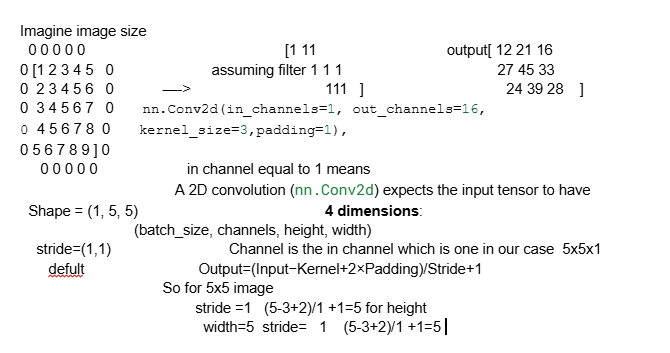

then we collect all the 32x16x5x5 and standatize them




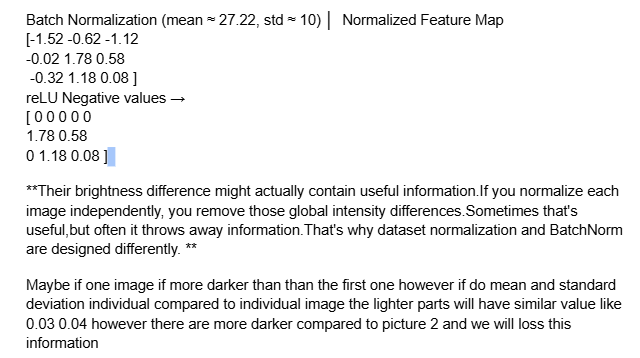


let 's consider we get from the first batch a 32x3x3x3 and we put that in channel so so conv2d will make filter of considering out channel 5x3x3x3 (batch size is not consier inside the filter )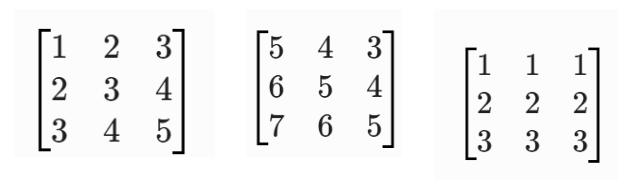


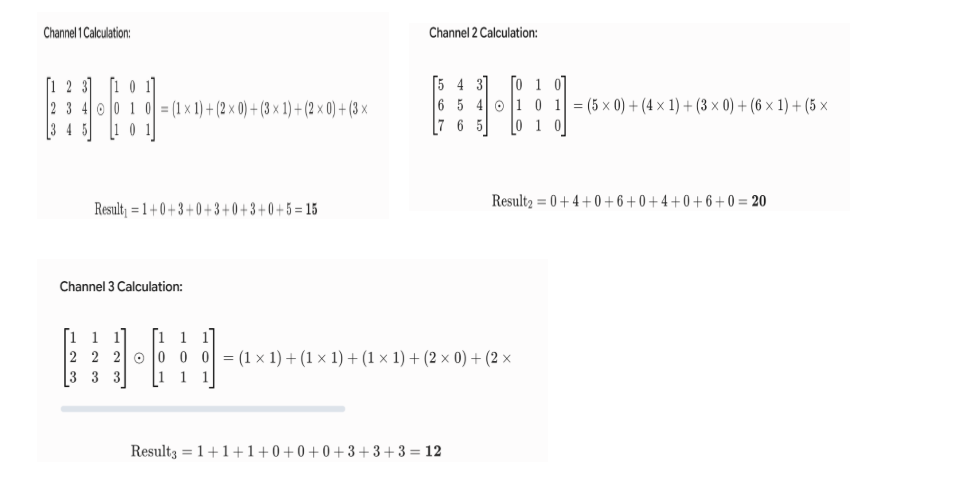

$$\text{Total} = \text{Result}_1 + \text{Result}_2 + \text{Result}_3 + \text{bias}$$$$\text{Total} = 15 + 20 + 12 + \text{bias} = \mathbf{47} + \text{bias}$$  we will have 3 filter 3x3 for each channel with dffrent weights and a bias 5 times because out channel 5 the output matrix would have diminsion 32x5x3x3  whch get updated with backpropogation also batch normalization mean and std also get updated

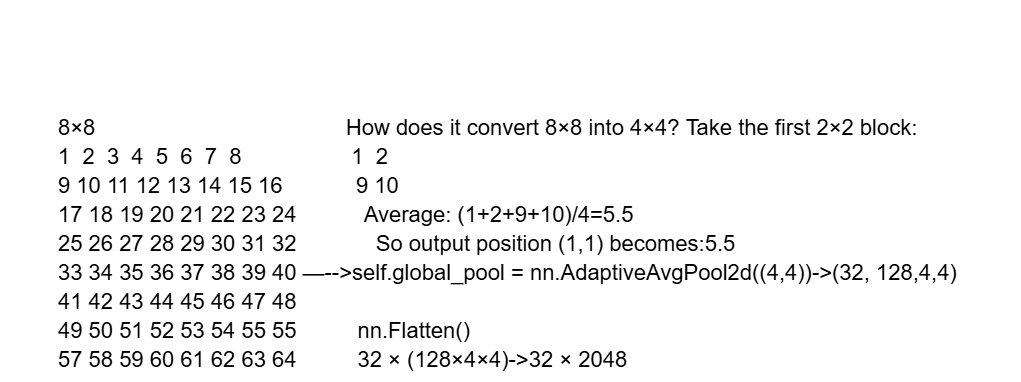

Entropy is the magnitude of surprise it is represented by -lop(p) we follow 1/p and not 1-p because umm we gain infinite information if we have zero knowledge and not 1 it basically enlarge the scaling and The form of h(·) can be found by noting that if we have two events x
and y that are unrelated, then the information gain from observing both of them
should be the sum of the information gained from each of them separately, so that
h(x, y) = h(x) + h(y). Two unrelated events will be statistically independent and
so p(x, y) = p(x)p(y). From these two relationships, it is easily shown that h(x)


 Consider some unknown distribution p(x), and suppose that
we have modelled this using an approximating distribution q(x). If we use q(x) to
construct a coding scheme for the purpose of transmitting values of x to a receiver,
then the average additional amount of information (in nats) required to specify the
value of x (assuming we choose an efficient coding scheme) as a result of using q(x)
instead of the true distribution p(x) is given by

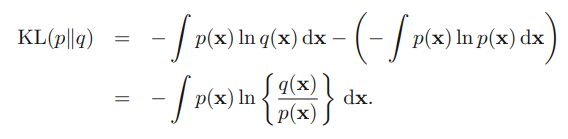

why not use :  $q(x) \ln q(x) - q(x) \ln p(x)$,  Since the real world behaves like $p(x)$, we must weight the penalty by $p(x)$. because we want model closer to p(x)

why use 4 block? because 4 blocks is deep enough and 3x3 is the standard we use because

In [13]:

# ============================================================
# MODEL: deeper CNN + BatchNorm, AdaptiveAvgPool so it's size-agnostic
# ============================================================
class AudioCNN(L.LightningModule):

    def __init__(self, num_classes, learning_rate=LEARNING_RATE):
        super().__init__()
        self.save_hyperparameters()

        self.conv_block = nn.Sequential(
            # block 1: 1 -> 16 channels
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # block 2: 16 -> 32 channels
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # block 3: 32 -> 64 channels
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # block 4: 64 -> 128 channels
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # AdaptiveAvgPool collapses any spatial size down to 4x4, so we never
        # have to hand-compute the flatten size (that was the Linear(4,1) bug)
        self.global_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, x):
        x = self.conv_block(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

    def _shared_step(self, batch, stage):
        inputs, labels = batch
        logits = self.forward(inputs)
        loss = self.loss_fn(logits, labels)
        preds = torch.argmax(logits, dim=1)
        acc = (preds == labels).float().mean()
        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log(f"{stage}_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self._shared_step(batch, "train")

    def validation_step(self, batch, batch_idx):
        return self._shared_step(batch, "val")

    def test_step(self, batch, batch_idx):
        return self._shared_step(batch, "test")

    def predict_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self.forward(inputs)
        preds = torch.argmax(logits, dim=1)
        return preds, labels

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=self.hparams.learning_rate)


In [14]:
# ============================================================
# TRAIN
# ============================================================
model = AudioCNN(num_classes=NUM_CLASSES)

logger = CSVLogger("logs", name="audio_cnn")
early_stop = EarlyStopping(monitor="val_loss", patience=8, mode="min")

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    logger=logger,
    callbacks=[early_stop],
    log_every_n_steps=10,
)
trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)





INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv_block  │ Sequential        │ 97.6 K │ train │     0 │
│ 1 │ global_pool │ AdaptiveAvgPool2d │      0 │ train │     0 │
│ 2 │ classifier  │ Sequential        │  529 K │ train │     0 │
│ 3 │ loss_fn     │ CrossEntropyLoss  │      0 │ train │     0 │
└───┴─────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 627 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 627 K                                                                                                
Total estimated model params size (MB): 2.508                                                                      
Modules in train mode: 25                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO: `Trainer.fit` stopped: `max_epochs=13` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=13` reached.


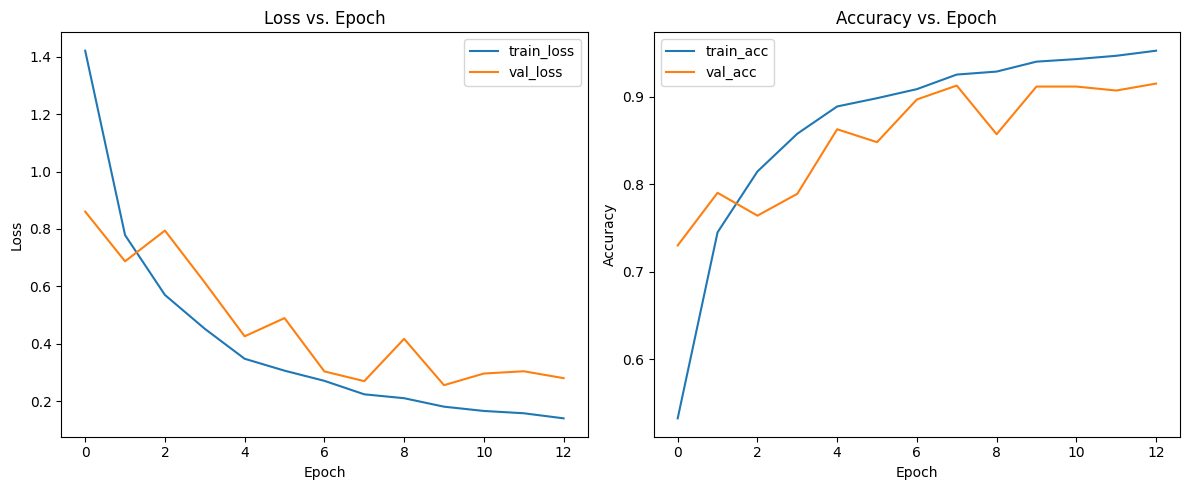

In [15]:

# PLOTS: training / validation loss + accuracy curves
# ============================================================
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")
metrics_epoch = metrics.groupby("epoch").mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(metrics_epoch["epoch"], metrics_epoch["train_loss"], label="train_loss")
if "val_loss" in metrics_epoch:
    axes[0].plot(metrics_epoch["epoch"], metrics_epoch["val_loss"], label="val_loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss vs. Epoch")
axes[0].legend()

axes[1].plot(metrics_epoch["epoch"], metrics_epoch["train_acc"], label="train_acc")
if "val_acc" in metrics_epoch:
    axes[1].plot(metrics_epoch["epoch"], metrics_epoch["val_acc"], label="val_acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs. Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


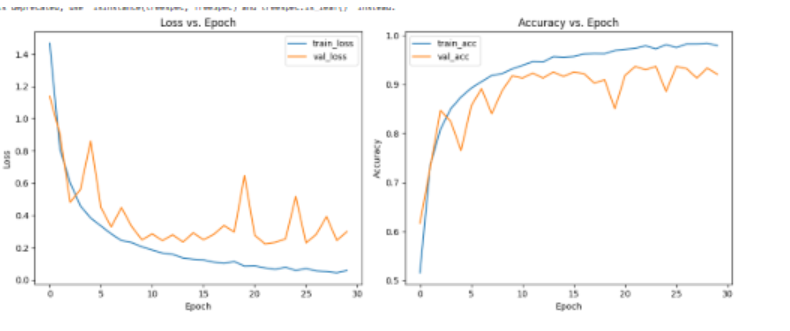

also tested for 30 epoches best was 92.32 so around 13 epouches were the best here tested for 12


Test accuracy: 0.9147

                 precision    recall  f1-score   support

    Asuna Yuuki       1.00      1.00      1.00       126
         Emilia       0.92      0.85      0.88       166
           Fern       0.93      0.98      0.95       129
        Frieren       0.99      0.93      0.96       260
   Homura Akemi       0.75      0.71      0.73        62
  Kurisu Makise       1.00      0.99      0.99       159
           Lucy       1.00      0.94      0.97        47
  Madoka Kaname       0.79      0.80      0.80        86
 Mai Sakurajima       0.75      0.96      0.84       109
         Makima       0.96      0.95      0.96        57
 Marin Kitagawa       0.98      0.99      0.99       212
        Megumin       0.89      0.85      0.87       134
Mikasa Ackerman       0.98      0.83      0.90        58
     Momo Ayase       0.85      0.99      0.92       130
          Power       0.92      0.92      0.92        39
            Rem       0.71      0.80      0.75        81
    Ri

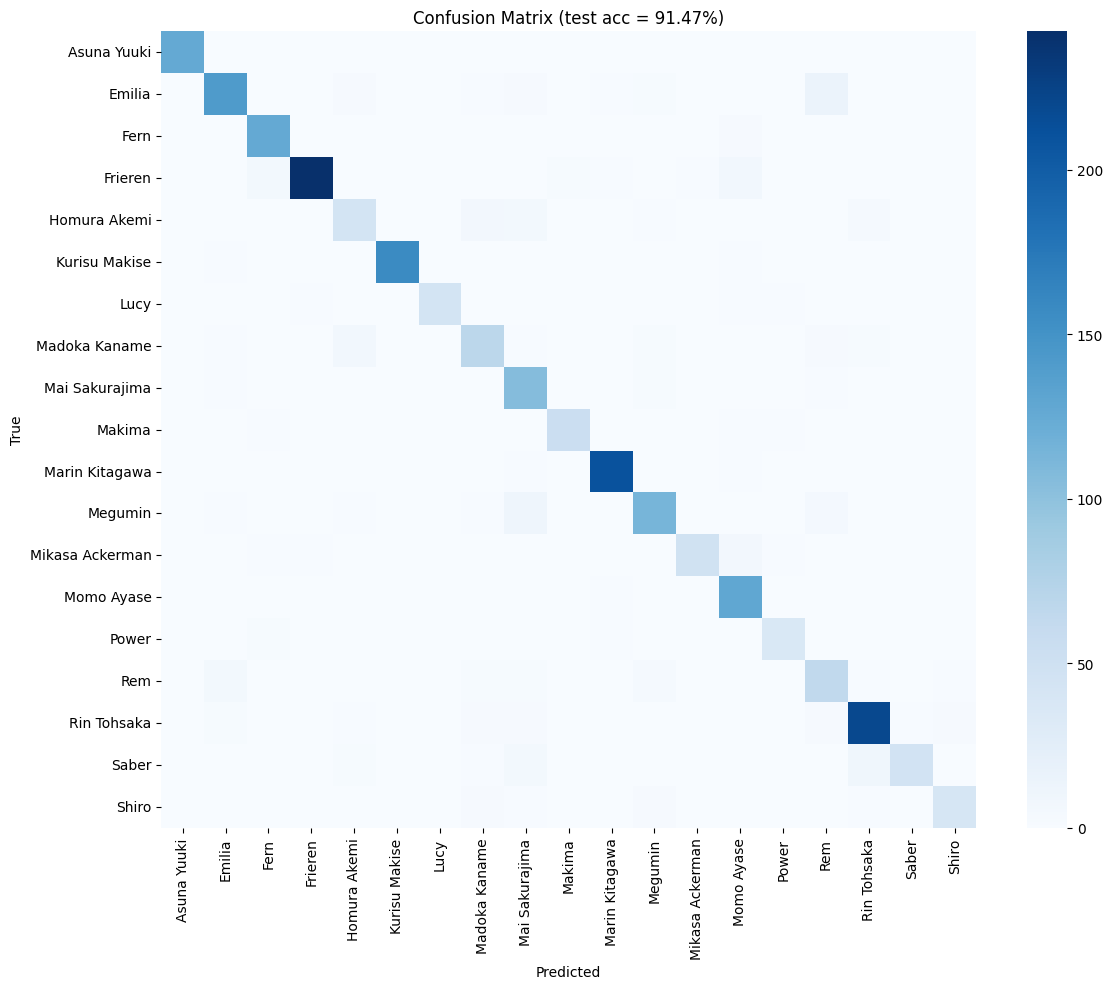

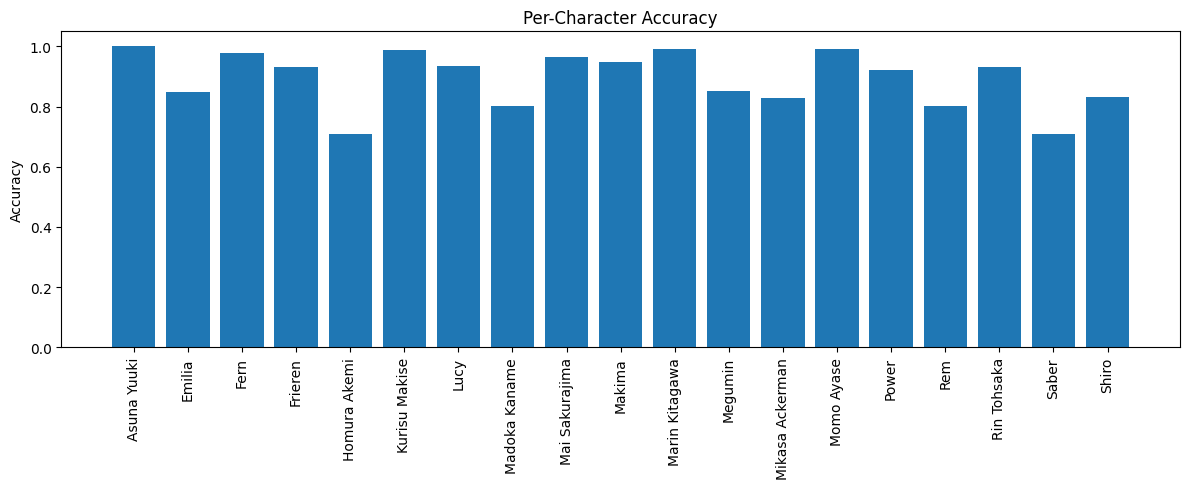

In [16]:
#
# ============================================================
# PREDICTION on held-out test set + evaluation graphs
# ============================================================
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for inputs, lbls in test_dataloader:
        logits = model(inputs)
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(lbls.cpu().numpy())

test_acc = accuracy_score(all_true, all_preds)
print(f"\nTest accuracy: {test_acc:.4f}\n")
print(classification_report(all_true, all_preds, target_names=encoder.classes_))

# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix (test acc = {test_acc:.2%})")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

# Per-class accuracy bar chart
per_class_acc = cm.diagonal() / cm.sum(axis=1)
plt.figure(figsize=(12, 5))
plt.bar(encoder.classes_, per_class_acc)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.title("Per-Character Accuracy")
plt.tight_layout()
plt.savefig("per_class_accuracy.png", dpi=150)
plt.show()


In [17]:

# Helper: predict a single new audio clip
# ============================================================
def predict_character(audio_array, sr):
    feats = extract_features(audio_array, sr)
    if feats is None:
        raise ValueError("Could not extract features from this audio.")
    feats_scaled = scaler.transform(feats.T).T
    x = torch.tensor(feats_scaled, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,N_MELS,FIXED_FRAMES)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = F.softmax(logits, dim=1).squeeze(0)
        pred_idx = torch.argmax(probs).item()
    return encoder.inverse_transform([pred_idx])[0], probs.numpy()

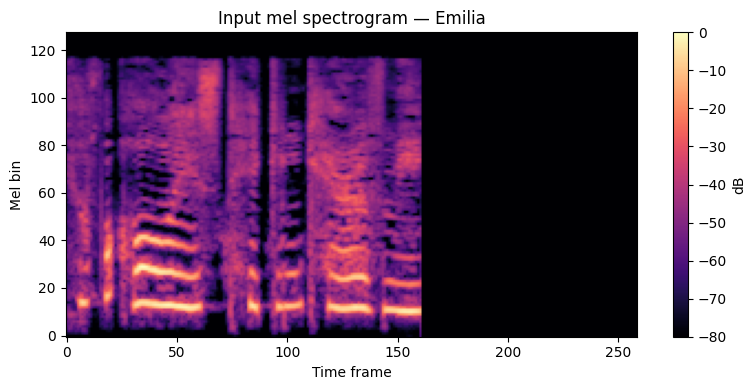

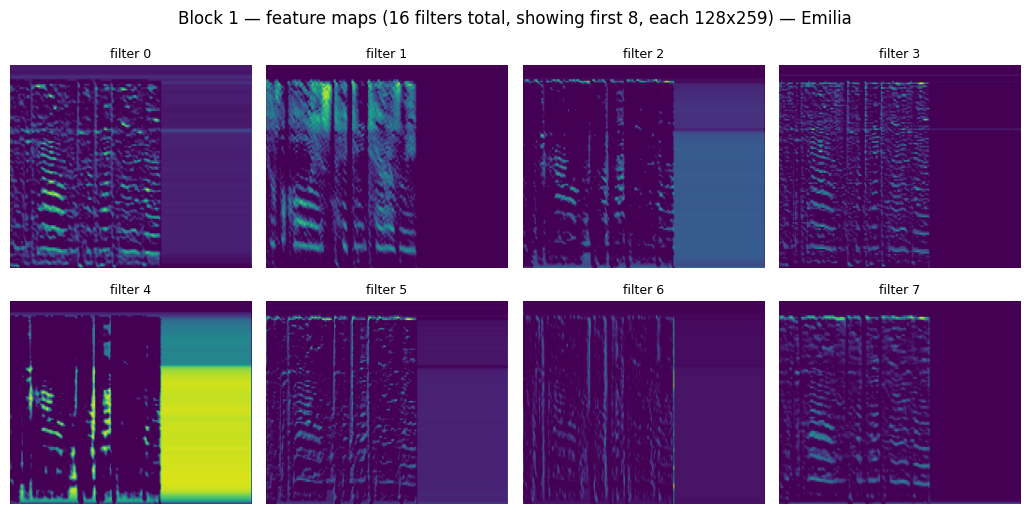

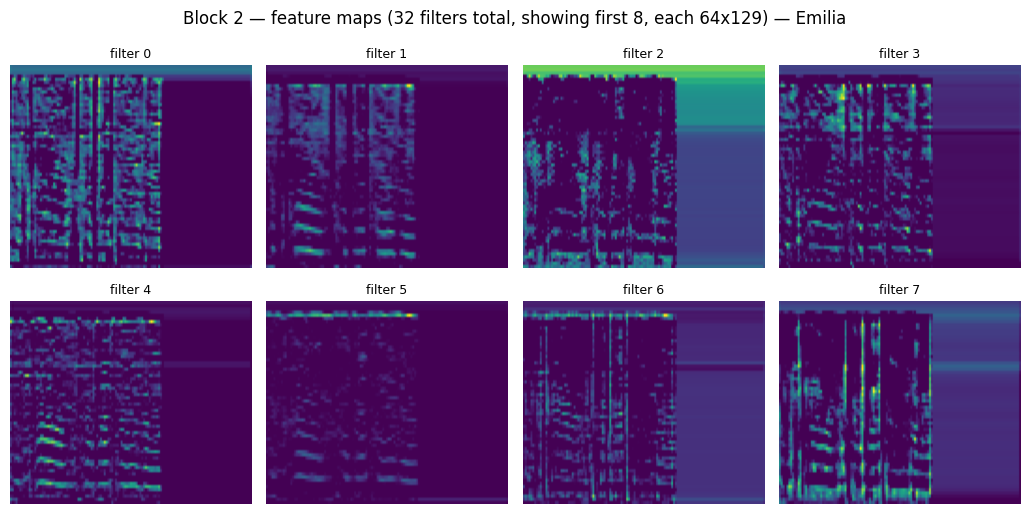

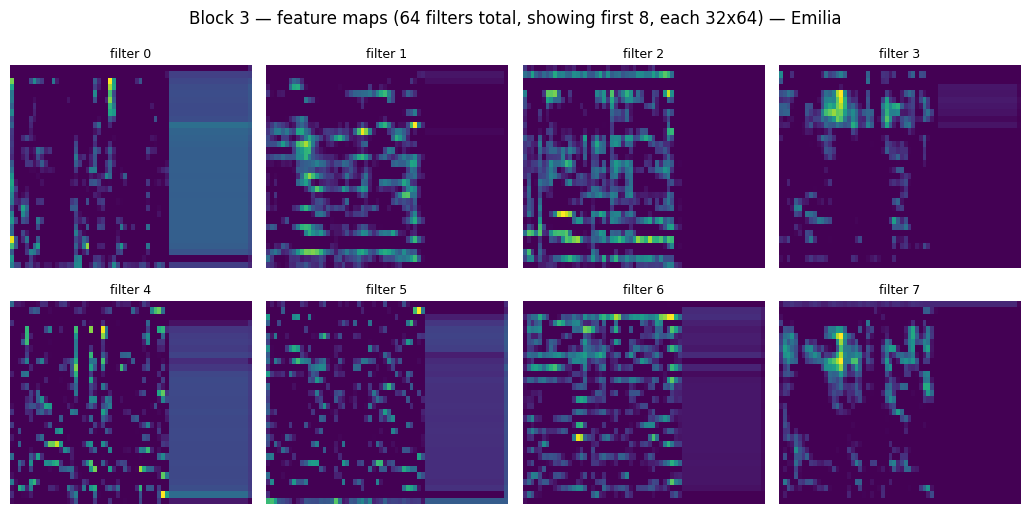

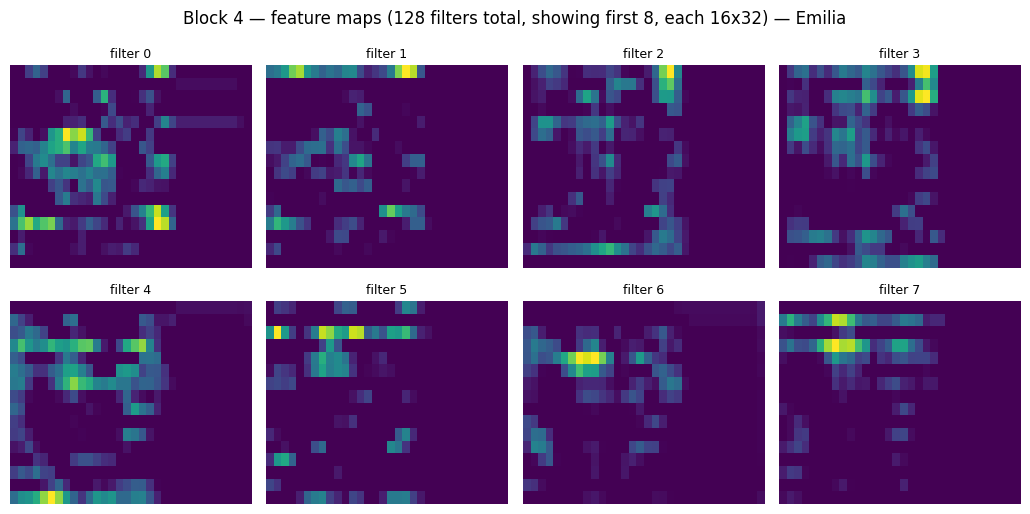

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import torch

def visualize_filters_on_spectrogram(
    model,
    feats_scaled,
    mel_spec_raw=None,
    character_name=None,
    max_channels=8,
    save_prefix="filters",
):

    """
    feats_scaled : (N_MELS, FIXED_FRAMES) array — the SCALED spectrogram you'd feed the model
                   (e.g. one entry from test_features_scaled)
    mel_spec_raw : optional (N_MELS, FIXED_FRAMES) array of the RAW log-mel spectrogram
                   (e.g. the matching entry from test_features), just for a nicer top plot
    character_name : optional label, only used in plot titles
    max_channels  : how many filters per layer to actually draw (blocks 3/4 have 64/128 -
                   plotting all of them isn't useful, so we sample the first N)
    """
    model.eval()
    x = torch.tensor(feats_scaled, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,N_MELS,FIXED_FRAMES)

    # ---- capture the output of every layer inside conv_block via forward hooks ----
    activations = {}
    hooks = []

    def make_hook(name):
        def hook(module, inp, out):
            activations[name] = out.detach()
        return hook

    for i, layer in enumerate(model.conv_block):
        name = f"{i:02d}_{layer.__class__.__name__}"
        hooks.append(layer.register_forward_hook(make_hook(name)))

    with torch.no_grad():
        model.conv_block(x)

    for h in hooks:
        h.remove()

    # ---- plot 1: the input spectrogram itself ----
    display_spec = mel_spec_raw if mel_spec_raw is not None else feats_scaled
    title_suffix = f" — {character_name}" if character_name else ""

    plt.figure(figsize=(8, 4))
    plt.imshow(display_spec, origin="lower", aspect="auto", cmap="magma")
    plt.title(f"Input mel spectrogram{title_suffix}")
    plt.xlabel("Time frame")
    plt.ylabel("Mel bin")
    plt.colorbar(label="dB" if mel_spec_raw is not None else "scaled value")
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_00_input.png", dpi=150)
    plt.show()

    # ---- plot 2: feature maps after each ReLU (post conv+batchnorm+relu, pre-pool) ----
    # each channel here = the output of one learned filter
    relu_layers = [name for name in activations if "ReLU" in name]

    for block_num, name in enumerate(relu_layers, start=1):
        fmap = activations[name].squeeze(0).cpu().numpy()  # (C, H, W)
        n_channels = fmap.shape[0]
        n_show = min(max_channels, n_channels)
        cols = 4
        rows = int(np.ceil(n_show / cols))

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 2.6))
        axes = np.array(axes).reshape(-1)

        for ch in range(n_show):
            axes[ch].imshow(fmap[ch], origin="lower", aspect="auto", cmap="viridis")
            axes[ch].set_title(f"filter {ch}", fontsize=9)
            axes[ch].axis("off")
        for ch in range(n_show, len(axes)):
            axes[ch].axis("off")

        fig.suptitle(
            f"Block {block_num} — feature maps ({n_channels} filters total, "
            f"showing first {n_show}, each {fmap.shape[1]}x{fmap.shape[2]}){title_suffix}"
        )
        plt.tight_layout()
        plt.savefig(f"{save_prefix}_{block_num:02d}_block.png", dpi=150)
        plt.show()

    return activations


def find_sample_by_character(character_name, features, features_scaled, labels):
    """Grab the first test sample matching a given character name."""
    for i, lbl in enumerate(labels):
        if lbl == character_name:
            return features[i], features_scaled[i]
    raise ValueError(f"No sample found for character '{character_name}'")


# ============================================================
# Example usage (uncomment and run after training):
# ============================================================

# Option A: just grab the first test sample
sample_char = test_labels[0]
activations = visualize_filters_on_spectrogram(
    model,
    feats_scaled=test_features_scaled[0],
    mel_spec_raw=test_features[0],
    character_name=sample_char,
)

# # Option B: pick a specific character by name
# raw, scaled = find_sample_by_character("homer_simpson", test_features, test_features_scaled, test_labels)
# activations = visualize_filters_on_spectrogram(
#     model, feats_scaled=scaled, mel_spec_raw=raw, character_name="homer_simpson"
# )